In [37]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [38]:
df = pd.read_csv("1- mental-illnesses-prevalence.csv")

EDA

In [39]:
df.shape

(6420, 8)

In [40]:
df.head()

,Entity,Code,Year,Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized,Depressive disorders (share of population) - Sex: Both - Age: Age-standardized,Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized,Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized,Eating disorders (share of population) - Sex: Both - Age: Age-standardized
0,Afghanistan,AFG,1990,0.223206,4.996118,4.713314,0.703023,0.127700
1,Afghanistan,AFG,1991,0.222454,4.989290,4.702100,0.702069,0.123256
2,Afghanistan,AFG,1992,0.221751,4.981346,4.683743,0.700792,0.118844
3,Afghanistan,AFG,1993,0.220987,4.976958,4.673549,0.700087,0.115089
4,Afghanistan,AFG,1994,0.220183,4.977782,4.670810,0.699898,0.111815


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6420 entries, 0 to 6419
Data columns (total 8 columns):
 #   Column                                                                             Non-Null Count  Dtype  
---  ------                                                                             --------------  -----  
 0   Entity                                                                             6420 non-null   object 
 1   Code                                                                               6150 non-null   object 
 2   Year                                                                               6420 non-null   int64  
 3   Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized  6420 non-null   float64
 4   Depressive disorders (share of population) - Sex: Both - Age: Age-standardized     6420 non-null   float64
 5   Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized        6420 non-null   float6

In [42]:
df.describe()

,Year,Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized,Depressive disorders (share of population) - Sex: Both - Age: Age-standardized,Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized,Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized,Eating disorders (share of population) - Sex: Both - Age: Age-standardized
count,6420.000000,6420.000000,6420.000000,6420.000000,6420.000000,6420.000000
mean,2004.500000,0.266604,3.767036,4.101840,0.636968,0.195664
std,8.656116,0.039383,0.925286,1.050543,0.233391,0.138380
min,1990.000000,0.188416,1.522333,1.879996,0.181667,0.044780
25%,1997.000000,0.242267,3.080036,3.425846,0.520872,0.096416
50%,2004.500000,0.273477,3.636772,3.939547,0.579331,0.144150
75%,2012.000000,0.286575,4.366252,4.564164,0.844406,0.251167
max,2019.000000,0.462045,7.645899,8.624634,1.506730,1.031688


In [43]:
df.isnull().sum()

Entity                                                                                 0
Code                                                                                 270
Year                                                                                   0
Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized      0
Depressive disorders (share of population) - Sex: Both - Age: Age-standardized         0
Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized            0
Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized            0
Eating disorders (share of population) - Sex: Both - Age: Age-standardized             0
dtype: int64

In [44]:
df.columns

Index(['Entity', 'Code', 'Year',
       'Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Depressive disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Eating disorders (share of population) - Sex: Both - Age: Age-standardized'],
      dtype='object')

In [45]:
df.select_dtypes(include='number').columns

Index(['Year',
       'Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Depressive disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Eating disorders (share of population) - Sex: Both - Age: Age-standardized'],
      dtype='object')

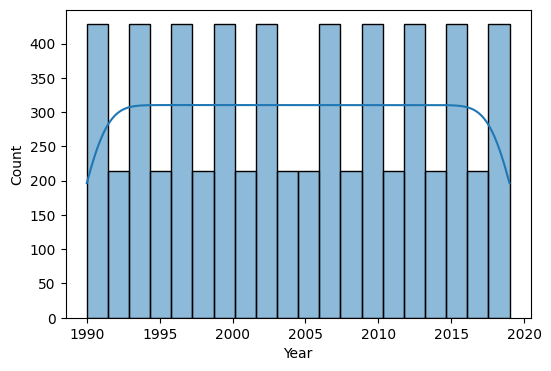

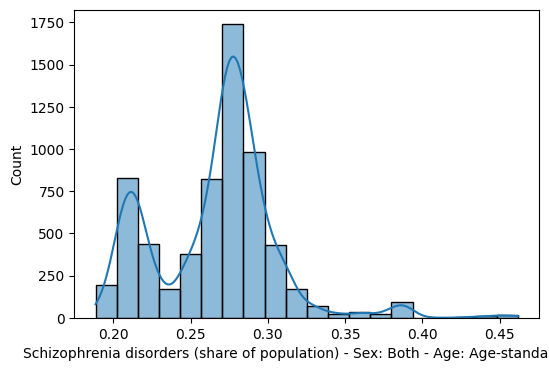

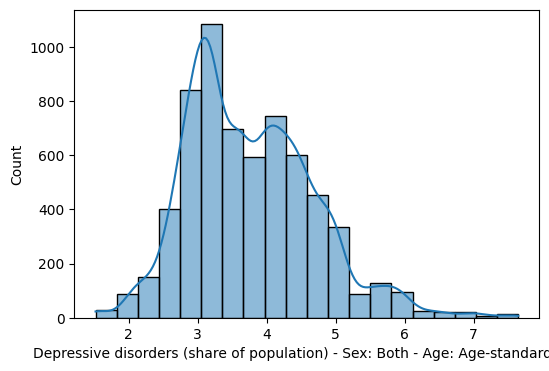

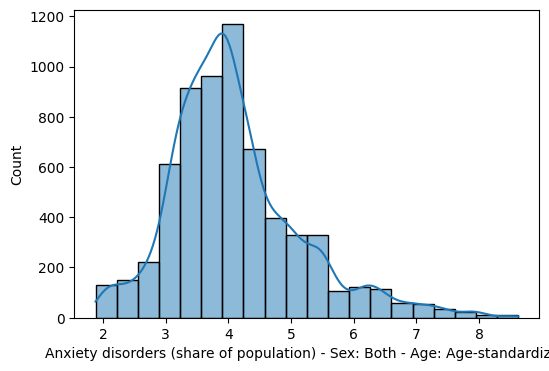

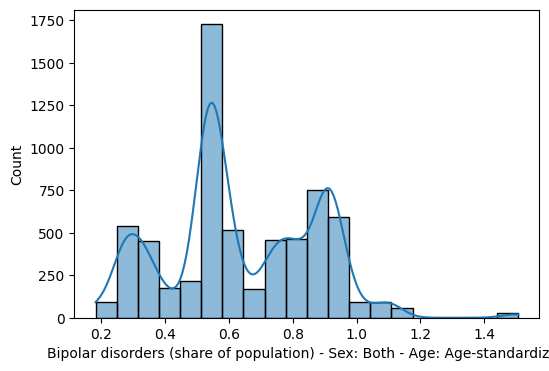

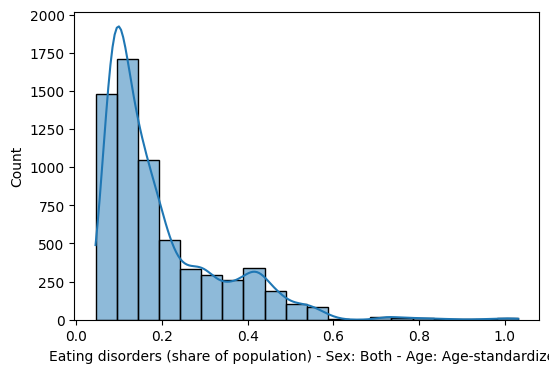

In [46]:
numeric_cols = ['Year',
       'Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Depressive disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Eating disorders (share of population) - Sex: Both - Age: Age-standardized']

for cols in numeric_cols:
  plt.figure(figsize=(6,4))
  sns.histplot(df[cols], kde=True, bins=20)

<Axes: xlabel='Entity', ylabel='count'>

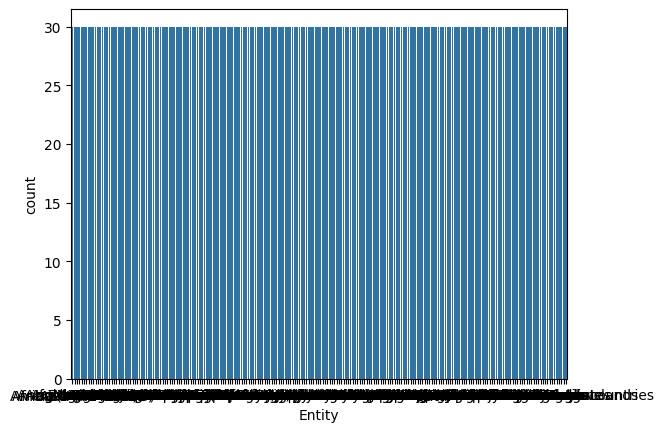

In [47]:
sns.countplot(x=df['Entity'])

<Axes: xlabel='Code', ylabel='count'>

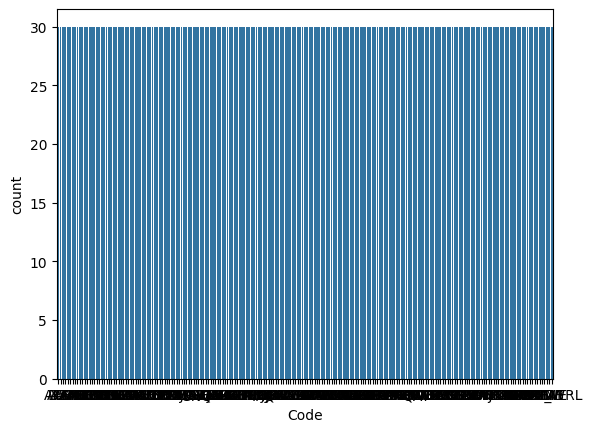

In [48]:
sns.countplot(x=df['Code'])

In [49]:
df['Entity'].value_counts()

Entity
Afghanistan           30
Africa (IHME GBD)     30
Albania               30
Algeria               30
America (IHME GBD)    30
                      ..
Vietnam               30
World                 30
Yemen                 30
Zambia                30
Zimbabwe              30
Name: count, Length: 214, dtype: int64

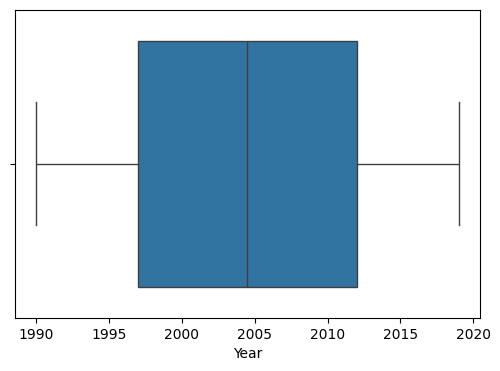

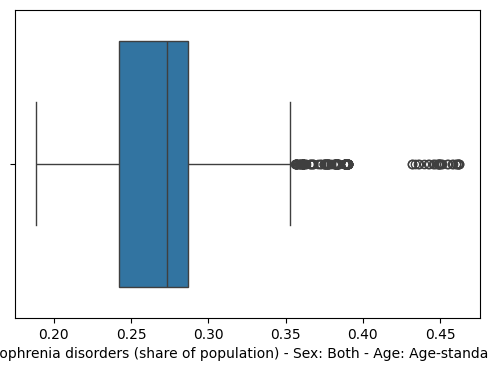

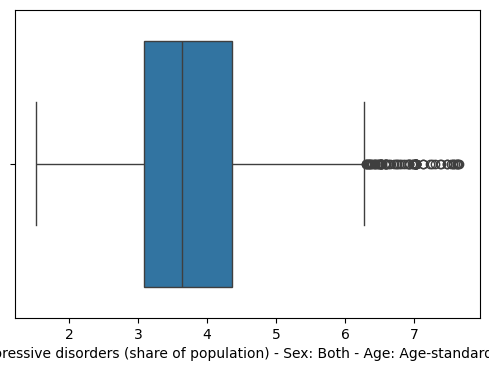

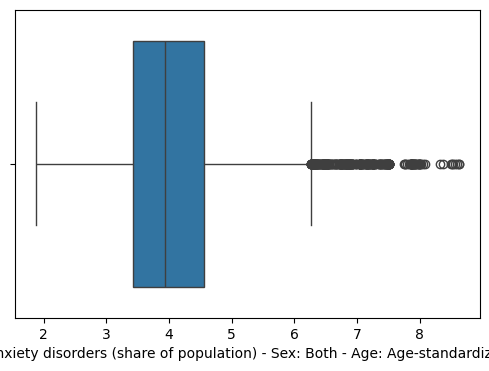

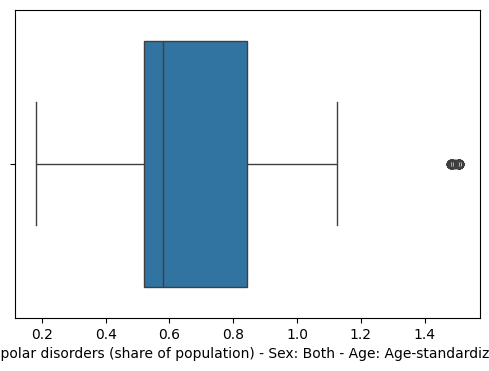

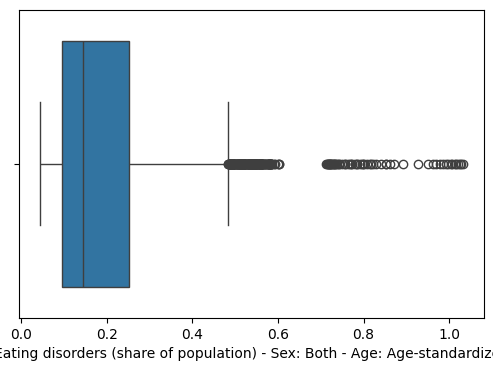

In [50]:
for col in numeric_cols:
  plt.figure(figsize=(6,4))
  sns.boxplot(x = df[col])

<Axes: >

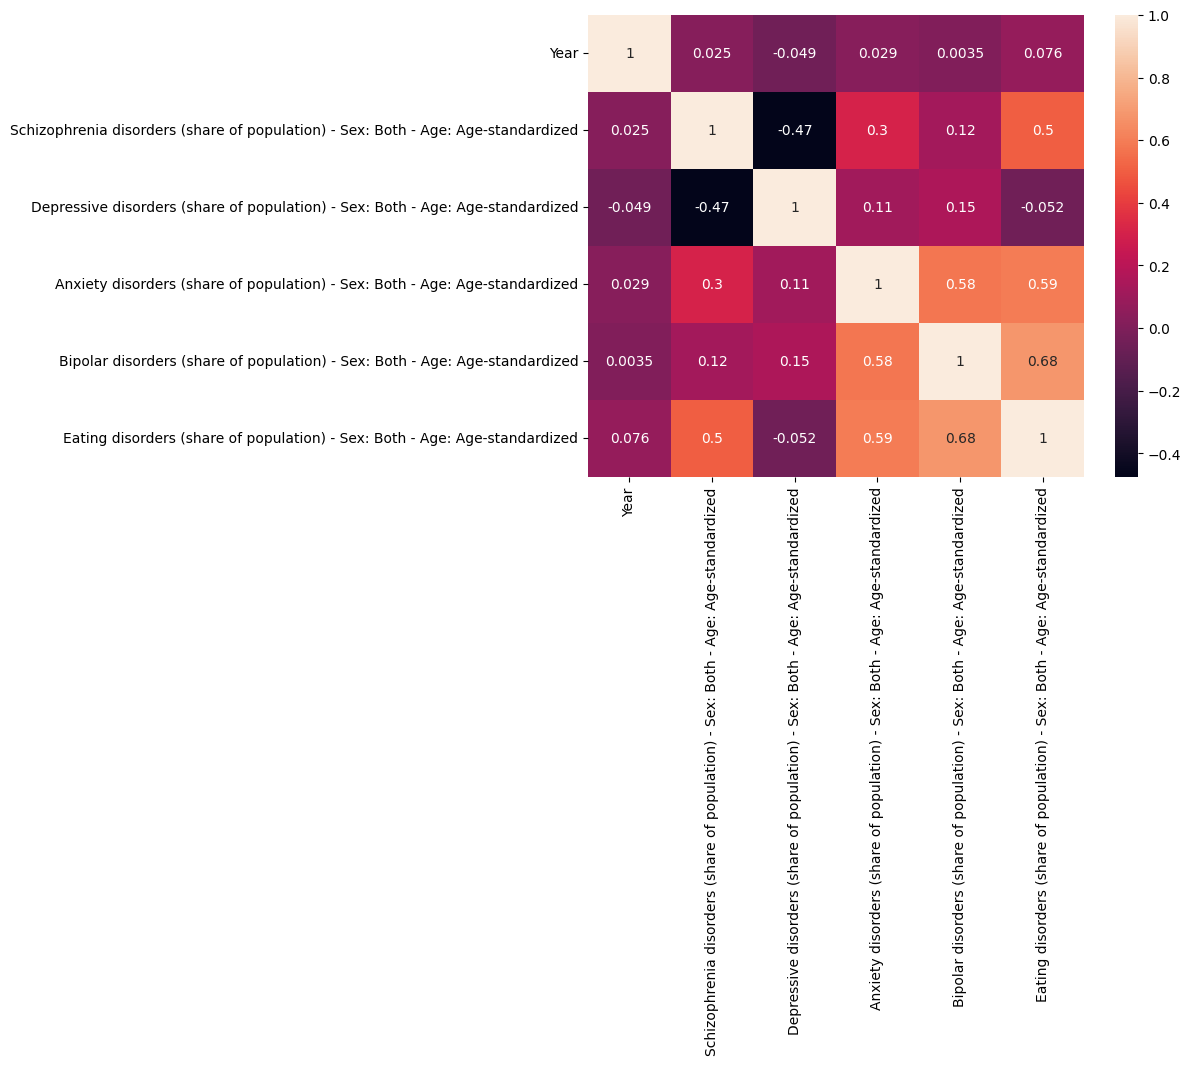

In [51]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

Bipolar ↔ Eating       0.68  ← strongest
Anxiety ↔ Eating       0.59
Anxiety ↔ Bipolar      0.58
Schizophrenia ↔ Eating 0.50
Schizophrenia ↔ Depression -0.47

The correlation heatmap shows that bipolar and eating disorders have the strongest positive correlation (0.68), followed by anxiety with eating disorders (0.59) and anxiety with bipolar disorders (0.58). Schizophrenia and depressive disorders show a moderate negative correlation (-0.47). The correlations between year and the disorder variables are close to zero, indicating little linear association with time.

Data Cleaning and Preprocessing


In [52]:
df_cleaned = df.copy()

In [53]:
df_cleaned.head()

,Entity,Code,Year,Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized,Depressive disorders (share of population) - Sex: Both - Age: Age-standardized,Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized,Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized,Eating disorders (share of population) - Sex: Both - Age: Age-standardized
0,Afghanistan,AFG,1990,0.223206,4.996118,4.713314,0.703023,0.127700
1,Afghanistan,AFG,1991,0.222454,4.989290,4.702100,0.702069,0.123256
2,Afghanistan,AFG,1992,0.221751,4.981346,4.683743,0.700792,0.118844
3,Afghanistan,AFG,1993,0.220987,4.976958,4.673549,0.700087,0.115089
4,Afghanistan,AFG,1994,0.220183,4.977782,4.670810,0.699898,0.111815


In [54]:
df_cleaned.shape

(6420, 8)

In [55]:
df_cleaned.dtypes

Entity                                                                                object
Code                                                                                  object
Year                                                                                   int64
Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized    float64
Depressive disorders (share of population) - Sex: Both - Age: Age-standardized       float64
Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized          float64
Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized          float64
Eating disorders (share of population) - Sex: Both - Age: Age-standardized           float64
dtype: object

In [56]:
df_cleaned = df_cleaned.drop(columns=['Code'])

In [57]:
df_cleaned.head()

,Entity,Year,Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized,Depressive disorders (share of population) - Sex: Both - Age: Age-standardized,Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized,Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized,Eating disorders (share of population) - Sex: Both - Age: Age-standardized
0,Afghanistan,1990,0.223206,4.996118,4.713314,0.703023,0.127700
1,Afghanistan,1991,0.222454,4.989290,4.702100,0.702069,0.123256
2,Afghanistan,1992,0.221751,4.981346,4.683743,0.700792,0.118844
3,Afghanistan,1993,0.220987,4.976958,4.673549,0.700087,0.115089
4,Afghanistan,1994,0.220183,4.977782,4.670810,0.699898,0.111815


In [58]:
df_cleaned.duplicated().sum()

np.int64(0)

In [59]:
df_cleaned.describe()

,Year,Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized,Depressive disorders (share of population) - Sex: Both - Age: Age-standardized,Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized,Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized,Eating disorders (share of population) - Sex: Both - Age: Age-standardized
count,6420.000000,6420.000000,6420.000000,6420.000000,6420.000000,6420.000000
mean,2004.500000,0.266604,3.767036,4.101840,0.636968,0.195664
std,8.656116,0.039383,0.925286,1.050543,0.233391,0.138380
min,1990.000000,0.188416,1.522333,1.879996,0.181667,0.044780
25%,1997.000000,0.242267,3.080036,3.425846,0.520872,0.096416
50%,2004.500000,0.273477,3.636772,3.939547,0.579331,0.144150
75%,2012.000000,0.286575,4.366252,4.564164,0.844406,0.251167
max,2019.000000,0.462045,7.645899,8.624634,1.506730,1.031688


In [60]:
disorder_cols = [
     'Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Depressive disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized',
       'Eating disorders (share of population) - Sex: Both - Age: Age-standardized'
]

corr = df_cleaned[disorder_cols].corr()

corr

,Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized,Depressive disorders (share of population) - Sex: Both - Age: Age-standardized,Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized,Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized,Eating disorders (share of population) - Sex: Both - Age: Age-standardized
Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized,1.000000,-0.474994,0.304149,0.121542,0.500656
Depressive disorders (share of population) - Sex: Both - Age: Age-standardized,-0.474994,1.000000,0.114429,0.153039,-0.052067
Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized,0.304149,0.114429,1.000000,0.576230,0.594511
Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized,0.121542,0.153039,0.576230,1.000000,0.677927
Eating disorders (share of population) - Sex: Both - Age: Age-standardized,0.500656,-0.052067,0.594511,0.677927,1.000000


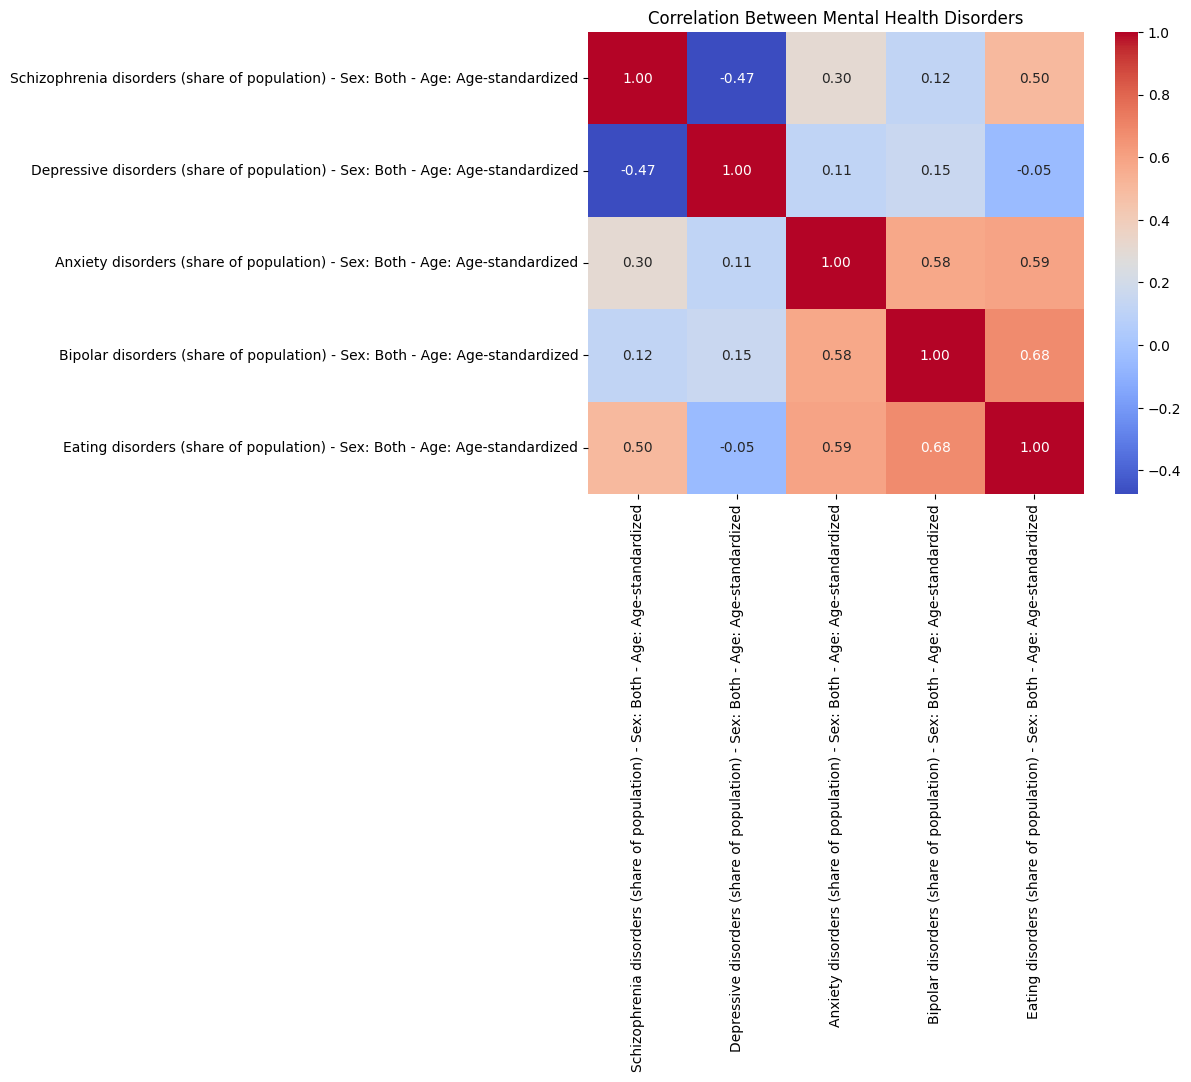

In [61]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Mental Health Disorders')
plt.show()

feature engineering and extraction

In [62]:
df_cleaned['Year'] = df['Year']

In [63]:
yearly_avg = df_cleaned.groupby('Year')[disorder_cols].mean()

In [64]:
yearly_avg.head()

,Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized,Depressive disorders (share of population) - Sex: Both - Age: Age-standardized,Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized,Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized,Eating disorders (share of population) - Sex: Both - Age: Age-standardized
Year,,,,,
1990,0.265545,3.816706,4.067391,0.635783,0.182725
1991,0.265602,3.814530,4.067576,0.635792,0.182770
1992,0.265644,3.812701,4.067882,0.635811,0.182909
1993,0.265672,3.811056,4.068179,0.635835,0.183126
1994,0.265682,3.809931,4.068545,0.635868,0.183419


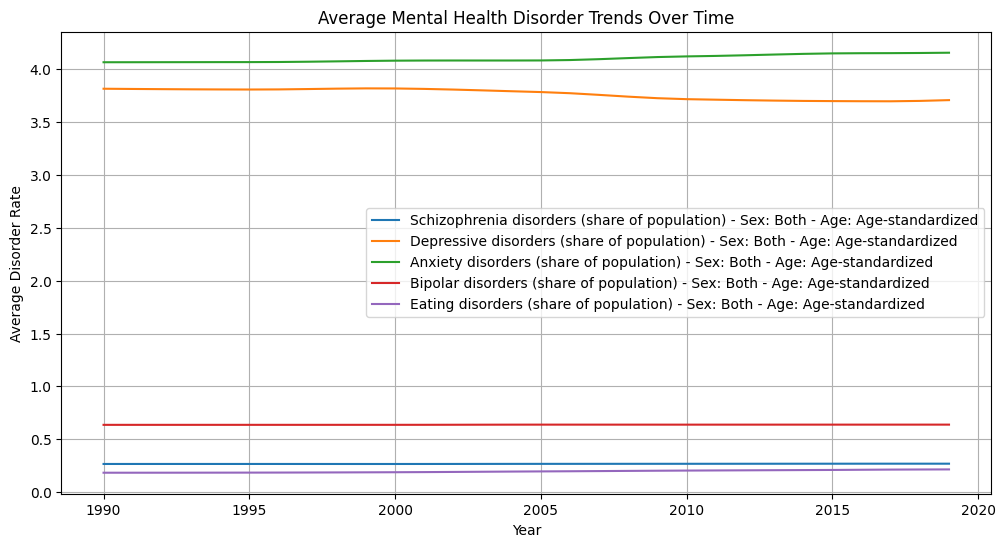

In [65]:
plt.figure(figsize=(12, 6))

for disorder in disorder_cols:
    plt.plot(yearly_avg.index, yearly_avg[disorder], label=disorder)

plt.xlabel('Year')
plt.ylabel('Average Disorder Rate')
plt.title('Average Mental Health Disorder Trends Over Time')
plt.legend()
plt.grid(True)
plt.show()